# Auto encoders

## Build a Denoising Convolutional Autoencoder on Devanagari

In [110]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print(np.__version__)
print(tf.config.list_physical_devices('GPU'))

1.26.4
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### load pre-process and add noise to dataset

In [101]:
import os
from PIL import Image

img_width, img_height = 28, 28
train_dir = "../week-4/dataset/Train/"
test_dir = "../week-4/dataset/Test/"

def load_images_from_folder(folder: str):
    """
    Load images from a folder structured as:
        folder/
            class_1/
                img1.png
                img2.png
            class_2/
                ...

    Args:
        folder (str): Path to the root dataset directory.

    Returns:
        tuple: (images, labels)
            - images (np.ndarray): Shape (N, 28, 28, 1), normalized to [0, 1].
            - labels (np.ndarray): Shape (N,), integer class indices.
    """
    class_names = sorted([
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d))  # skip hidden files / non-dirs
    ])
    class_map = {name: i for i, name in enumerate(class_names)}

    images, labels = [], []
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        count = 0
        for filename in os.listdir(class_path):
            if not filename.endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img, dtype="float32") / 255.0
            img = img.reshape(28, 28, 1)
            images.append(img)
            labels.append(label)
            count += 1

    images = np.array(images)
    labels = np.array(labels)

    print(f"\nTotal: {len(images)} images")
    print(f"Shape: {images.shape}")
    print(f"Pixel range: [{images.min():.4f}, {images.max():.4f}]")
    print(f"Labels: {np.unique(labels)}")

    return images, labels
    
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)


Total: 17000 images
Shape: (17000, 28, 28, 1)
Pixel range: [0.0000, 1.0000]
Labels: [0 1 2 3 4 5 6 7 8 9]

Total: 3000 images
Shape: (3000, 28, 28, 1)
Pixel range: [0.0000, 1.0000]
Labels: [0 1 2 3 4 5 6 7 8 9]


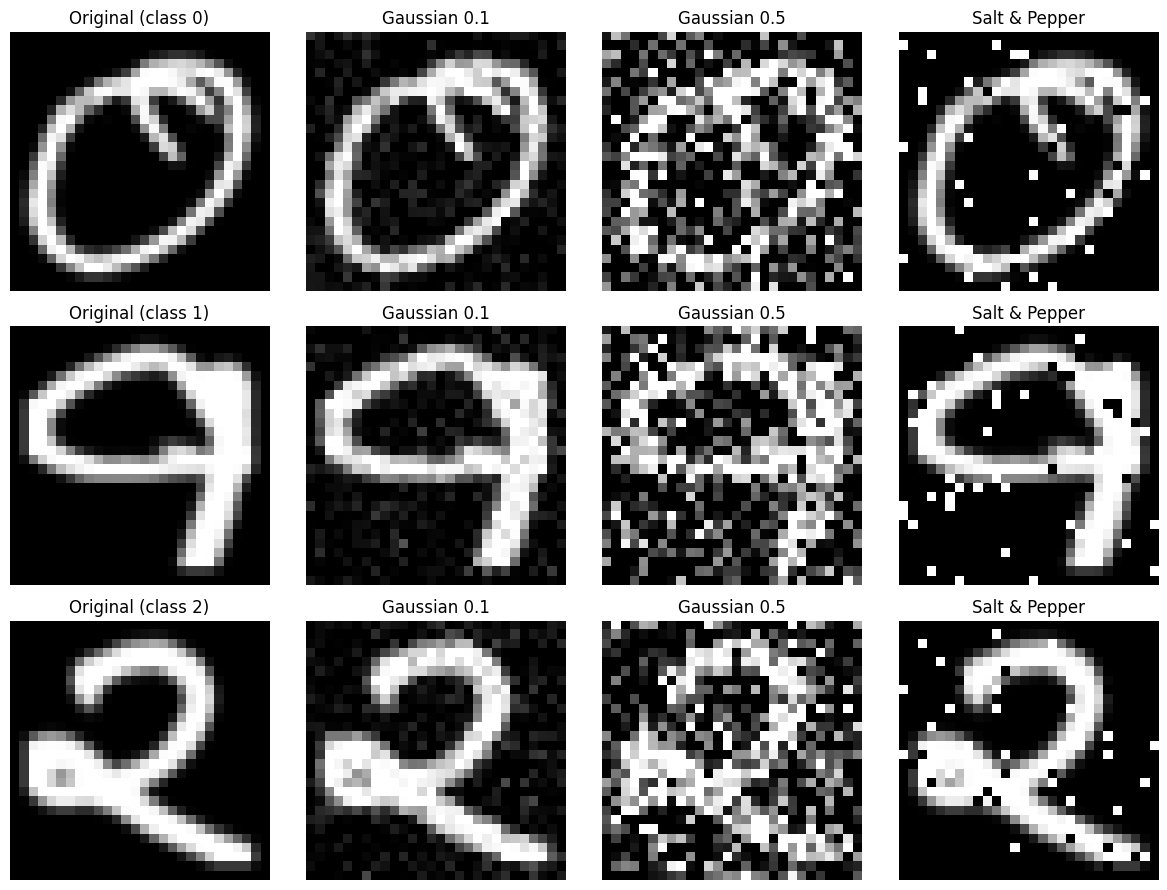

In [102]:
def add_gaussian_noise(images, noise_factor=0.5):
    """
    Add Gaussian noise to images.

    Args:
        images (np.ndarray): Array of images with pixel values in [0, 1].
        noise_factor (float): Scaling factor for noise intensity. Higher = more noise.

    Returns:
        np.ndarray: Noisy images clipped to [0, 1].
    """
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0., 1.)


def add_salt_pepper_noise(images, amount=0.05):
    """
    Add salt-and-pepper noise to images.

    Salt sets random pixels to 1.0 (white).
    Pepper sets random pixels to 0.0 (black).

    Args:
        images (np.ndarray): Array of images with pixel values in [0, 1].
        amount (float): Fraction of pixels to corrupt per image. Default is 0.05 (5%).

    Returns:
        np.ndarray: Noisy images with salt and pepper applied.
    """
    noisy = np.copy(images)
    num_pixels = int(np.ceil(amount * images[0].size))

    for img in noisy:
        # salt — white pixels
        salt_coords = [np.random.randint(0, i, num_pixels) for i in img.shape[:2]]
        img[salt_coords[0], salt_coords[1]] = 1.0
        # pepper — black pixels
        pepper_coords = [np.random.randint(0, i, num_pixels) for i in img.shape[:2]]
        img[pepper_coords[0], pepper_coords[1]] = 0.0

    return noisy


# generate noisy versions
x_train_noisy_low  = add_gaussian_noise(x_train, noise_factor=0.1)
x_train_noisy_high = add_gaussian_noise(x_train, noise_factor=0.5)
x_test_noisy_low   = add_gaussian_noise(x_test,  noise_factor=0.1)
x_test_noisy_high  = add_gaussian_noise(x_test,  noise_factor=0.5)

x_train_noisy_sp   = add_salt_pepper_noise(x_train, amount=0.05)
x_test_noisy_sp    = add_salt_pepper_noise(x_test,  amount=0.05)


n_classes = 10
indices = [np.random.choice(np.where(y_train == i)[0]) for i in range(n_classes)]

# show first 3 classes
plt.figure(figsize=(12, 9))
for row, idx in enumerate(indices[:3]):
    plt.subplot(3, 4, row * 4 + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Original (class {y_train[idx]})"); plt.axis("off")

    plt.subplot(3, 4, row * 4 + 2)
    plt.imshow(x_train_noisy_low[idx].reshape(28, 28), cmap="gray")
    plt.title("Gaussian 0.1"); plt.axis("off")

    plt.subplot(3, 4, row * 4 + 3)
    plt.imshow(x_train_noisy_high[idx].reshape(28, 28), cmap="gray")
    plt.title("Gaussian 0.5"); plt.axis("off")

    plt.subplot(3, 4, row * 4 + 4)
    plt.imshow(x_train_noisy_sp[idx].reshape(28, 28), cmap="gray")
    plt.title("Salt & Pepper"); plt.axis("off")

plt.tight_layout()
plt.show()

### build an encoder

In [103]:
from tensorflow.keras import layers

def build_encoder(input_shape=(28, 28, 1)):
    """ 
    Builds the encoder  part of convolutional autoencoder.

    Parameters:
        input_shape (tuple): Shape of input image. Defaults to (28, 28, 1)  for MNIST

    Returns: 
        input_img (Keras Input): Input layer of the model
        encoded (Keras Tensor) : Encoded representation after convolution and pooling
    """
    input_img = layers.Input(shape=input_shape, name="input")
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same", name="encoded")(x)
    return input_img, encoded 

### build a decoder 

In [104]:
def build_decoder(encoded_input):
    """ 
    Builds the decoder  part of convolutional autoencoder.

    Parameters:
        encoded_input (keras Tensor): The output from the encoder

    Returns: 
        decoded (Keras Tensor) : The reconstructed output after upsampling
    """
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoded')(x)
    return decoded

### build autoencoder

In [105]:
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting the encoder and decoder part 

    Returns: 
        autoencoder(Keras Model): Compiled autoencoder model
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_input=encoded_output)
    autoencoder = keras.Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return autoencoder

### compile the model

In [106]:
autoencoder = build_autoencoder();
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test),
    verbose=1
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6514 - loss: 0.2951 - val_accuracy: 0.6720 - val_loss: 0.2132
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6729 - loss: 0.2073 - val_accuracy: 0.6740 - val_loss: 0.2000
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6740 - loss: 0.1992 - val_accuracy: 0.6744 - val_loss: 0.1958
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6744 - loss: 0.1951 - val_accuracy: 0.6747 - val_loss: 0.1934
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6747 - loss: 0.1921 - val_accuracy: 0.6749 - val_loss: 0.1899
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6749 - loss: 0.1897 - val_accuracy: 0.6751 - val_loss: 0.1879
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6750 - loss: 0.1882 - val_accuracy: 0.6752 - val_loss: 0.1867
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6751 - loss: 0.1869 - val_accuracy

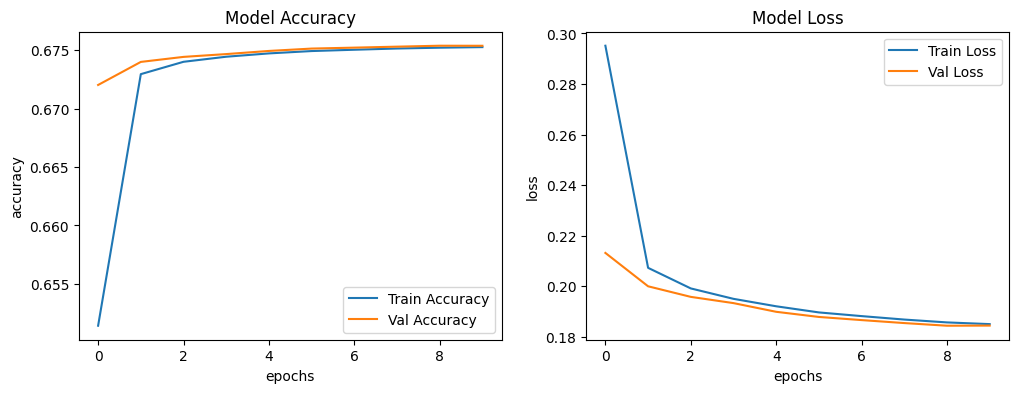

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


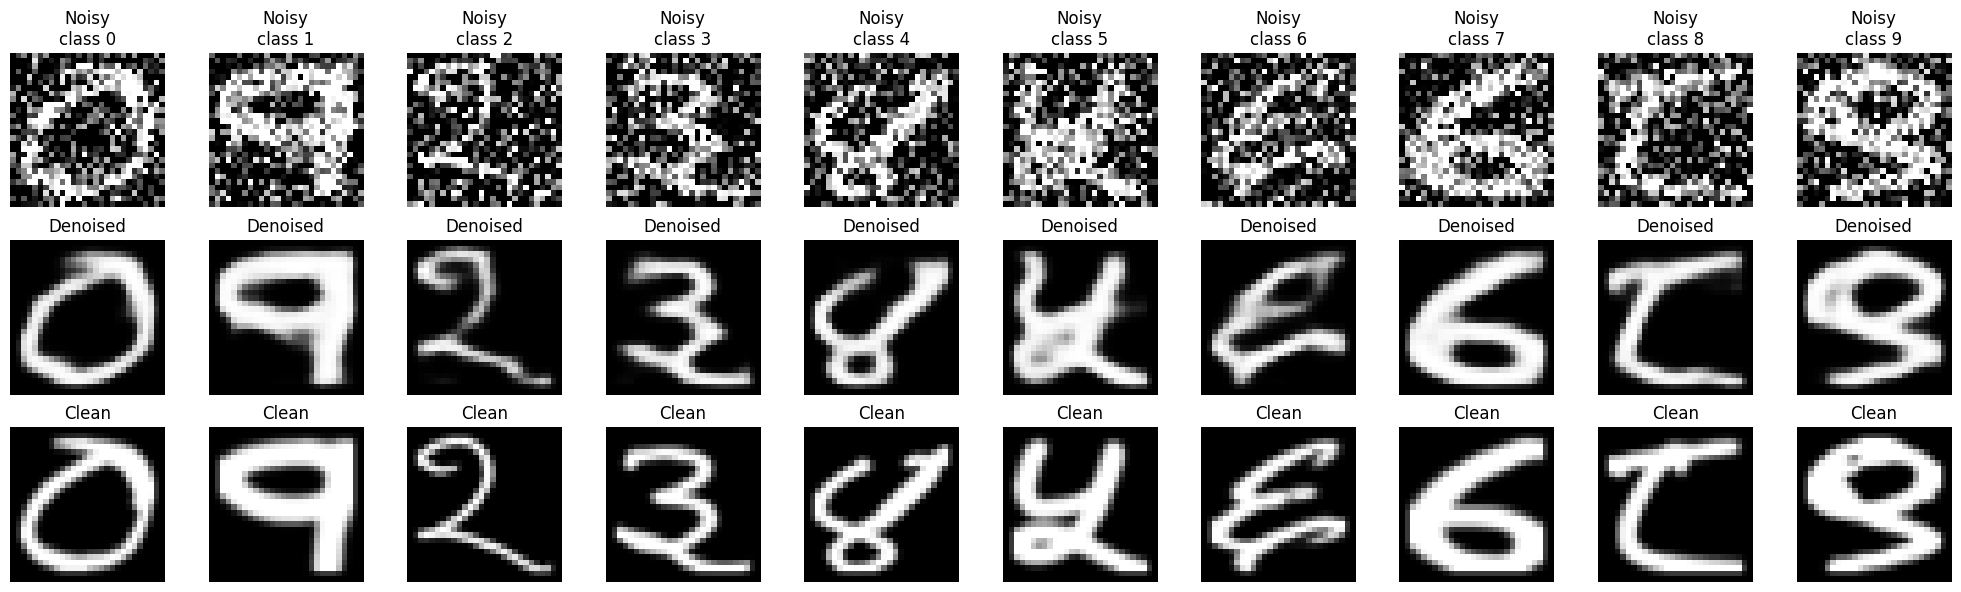

In [109]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

def plot_images(noisy_images, denoised_images, clean_images, labels, n=10):
    """
    Display noisy, denoised, and clean images side by side.

    Args:
        noisy_images (np.ndarray): Noisy input images.
        denoised_images (np.ndarray): Autoencoder reconstructed images.
        clean_images (np.ndarray): Original clean images.
        labels (np.ndarray): Class labels for selecting one per class.
        n (int): Number of images to display.
    """
    # pick one random image from each class
    indices = [np.random.choice(np.where(labels == i)[0]) for i in range(n)]

    plt.figure(figsize=(20, 6))
    for col, idx in enumerate(indices):
        plt.subplot(3, n, col + 1)
        plt.imshow(noisy_images[idx].reshape(28, 28), cmap='gray')
        plt.title(f"Noisy\nclass {labels[idx]}")
        plt.axis('off')

        plt.subplot(3, n, col + 1 + n)
        plt.imshow(denoised_images[idx].reshape(28, 28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        plt.subplot(3, n, col + 1 + 2 * n)
        plt.imshow(clean_images[idx].reshape(28, 28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_images(x_test_noisy_high, denoised_images, x_test, y_test, n=10)